In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = pd.read_excel("/content/Rent.csv")
df.head()

,area,rent
0,2000,31500
1,2100,35000
2,2500,41050
3,2250,36100
4,3000,52100


In [6]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    60 non-null     int64
 1   rent    60 non-null     int64
dtypes: int64(2)
memory usage: 1.1 KB
None
              area          rent
count    60.000000     60.000000
mean   2289.000000  37269.166667
std     538.880509  11770.736234
min    1200.000000  20000.000000
25%    1900.000000  31000.000000
50%    2130.000000  34450.000000
75%    2700.000000  47625.000000
max    3500.000000  70500.000000


In [7]:
X = df[['area']]
y = df['rent']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)
y_pred

array([31083.36419012, 28934.68187439, 20339.95261148, 54718.86966312,
       42041.64400032, 48272.82271593, 36455.06997943, 26785.99955866,
       33232.04650584, 26785.99955866, 26785.99955866, 33446.91473742])

In [11]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: -11890.282124432139
Coefficient: 21.486823157273594


In [12]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE : 1984.6279386790573
MSE : 5199691.621721148
RMSE: 2280.2832327851615
R² Score: 0.9370648048191109


In [13]:
results = pd.DataFrame({
    "Actual Rent": y_test.values,
    "Predicted Rent": y_pred
})

results

,Actual Rent,Predicted Rent
0,31500,31083.364190
1,32500,28934.681874
2,20200,20339.952611
3,51000,54718.869663
4,40050,42041.644000
5,51000,48272.822716
6,35100,36455.069979
7,25500,26785.999559
8,34500,33232.046506
9,25100,26785.999559


In [14]:
new_area = pd.DataFrame({'area': [2500]})

predicted_rent = model.predict(new_area)

print("Predicted Rent:", predicted_rent[0])

Predicted Rent: 41826.775768751846


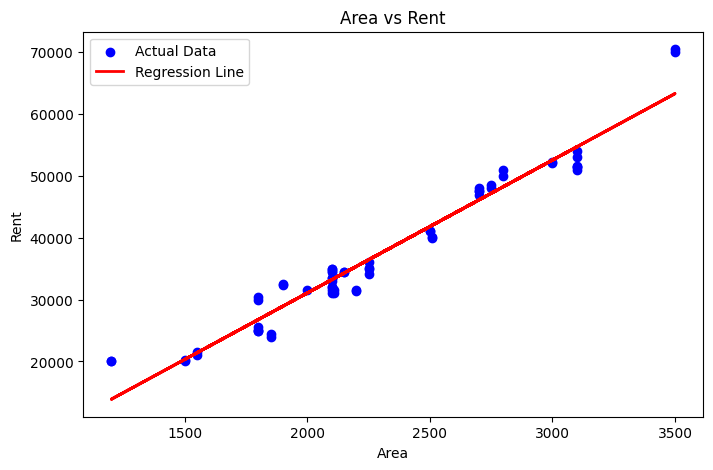

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')

plt.title("Area vs Rent")
plt.xlabel("Area")
plt.ylabel("Rent")
plt.legend()
plt.show()